In [1]:
'''
Demo of beam hardening correction with simulated spectrum.
'''

'\nDemo of beam hardening correction with simulated spectrum.\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

import pcct_md_diffusion.utils as utils
from pcct_md_diffusion.utils import load_nist_attenuation
from pcct_md_diffusion.locations import base_input_dir


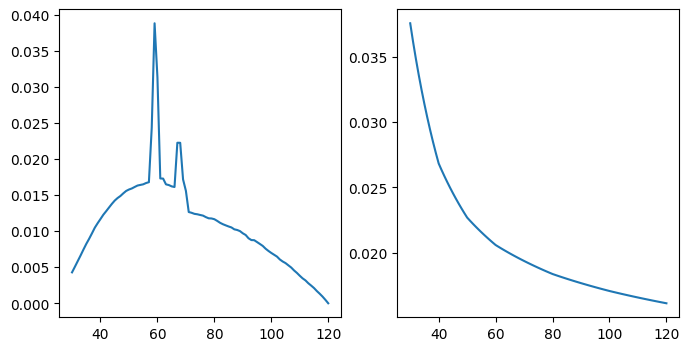

In [3]:
df = pd.read_csv(os.path.join(base_input_dir, 'spectrum/xray/spektr_120kVp_Be2p0_Cu0p127_omnitom.csv'))
df = df[df['Energy_keV'] >= 30]

energies = df['Energy_keV'].values
spectrum = df['Photons'].values
spectrum /= np.sum(spectrum)  # normalize

# Load NIST attenuation data for water
df = load_nist_attenuation(os.path.join(base_input_dir, 'spectrum/NIST/water.txt'), kevs=energies)
water_att = df['mu'].values

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(energies, spectrum)
plt.subplot(1, 2, 2)
plt.plot(df['Energy'], df['mu'])
plt.show()

0.019878219829105332


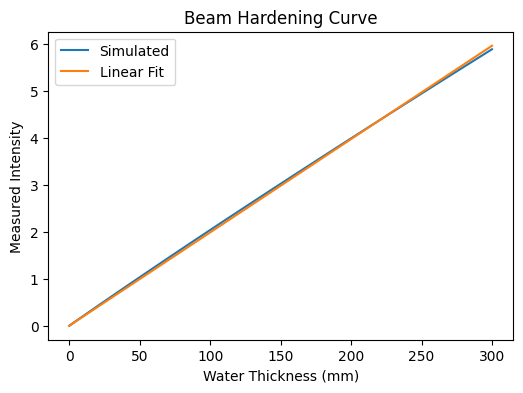

In [4]:
# The beam hardening curve
thicknesses = np.linspace(0, 300, 100)  # mm
attenuation = np.exp(-thicknesses[:, None] * water_att[None, :])
intensity = -np.log(np.sum(spectrum[None, :] * attenuation, axis=1))
intensity[intensity < 0] = 0

# fit to y=kx
k = np.linalg.lstsq(thicknesses[:, None], intensity, rcond=None)[0][0]
print(k)
display_vmin = k - 0.0005
display_vmax = k + 0.0005

plt.figure(figsize=(6, 4))
plt.plot(thicknesses, intensity, label='Simulated')
plt.plot(thicknesses, k * thicknesses, label='Linear Fit')
plt.xlabel('Water Thickness (mm)')
plt.ylabel('Measured Intensity')
plt.legend()
plt.title('Beam Hardening Curve')
plt.show()


======== CT Parallel-Beam Geometry ========
number of angles: 720
number of detector elements (rows, cols): 1 x 1756
angular range: 180.000000 degrees
detector pixel size: 1.000000 mm x 0.175785 mm
center detector pixel: 0.000000, 877.500000

======== CT Volume ========
number of voxels (x, y, z): 512 x 512 x 1
voxel size: 0.500000 mm x 0.500000 mm x 1.000000 mm
FOV: [-128.000000, 128.000000] x [-128.000000, 128.000000] x [-0.500000, 0.500000]

======== Processing Settings ========
GPU processing on devices 0, 1, 2
Forward projecting...GPU with least amount of memory: 35.170753 GB




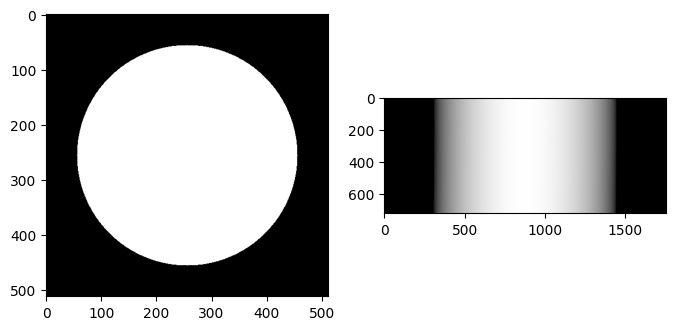

In [5]:
# simulate multi energy project of centered water phantom
phantom_diamter = 200 # mm
pixel_size = 0.5 # mm
img = np.zeros([1, 512, 512], dtype=np.float32)  # standard image size
cx = img.shape[2] // 2
cy = img.shape[1] // 2
x = (np.arange(img.shape[2]) - cx) * pixel_size
y = (np.arange(img.shape[1]) - cy) * pixel_size
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
img[0, R <= phantom_diamter / 2] = 1.0

# geometry already after interleaving
geometry_path = os.path.join(base_input_dir, 'omnitom_pcd/geometry/omnitom_3x3_parallel_fov_308.cfg')
geo = utils.load_geometry(geometry_path)
geo.nx = img.shape[-1]
geo.ny = img.shape[-2]
geo.nz = img.shape[-3]
geo.nv = geo.nz
geo.dx = pixel_size
geo.dy = pixel_size
geo.dz = 1
geo.dv = 1
geo.nu *= 2
geo.du /= 2
geo.nview = 720
geo.off_u = 0
leapct = utils.set_leapct_geometry(geo, angles_in_deg=np.arange(0, 180, 180.0 / geo.nview).astype(np.float32))
leapct.print_parameters()

print('Forward projecting...', flush=True)
prjs = leapct.allocate_projections()
_ = leapct.project(prjs, img)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img[0], cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(prjs[:, 0, :], cmap='gray')

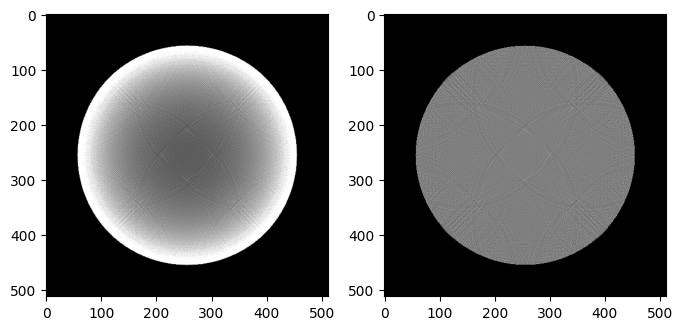

In [6]:
# simulate BHC
prjs_poly = -np.log(np.sum(np.exp(-prjs[..., None] * water_att) * spectrum, axis=-1)).astype(np.float32)
recon_poly = leapct.FBP(prjs_poly)

recon_mono = leapct.FBP((prjs * k).astype(np.float32))

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(recon_poly[0], cmap='gray', vmin=display_vmin, vmax=display_vmax)
plt.subplot(1, 2, 2)
plt.imshow(recon_mono[0], cmap='gray', vmin=display_vmin, vmax=display_vmax)

1.019915216355136


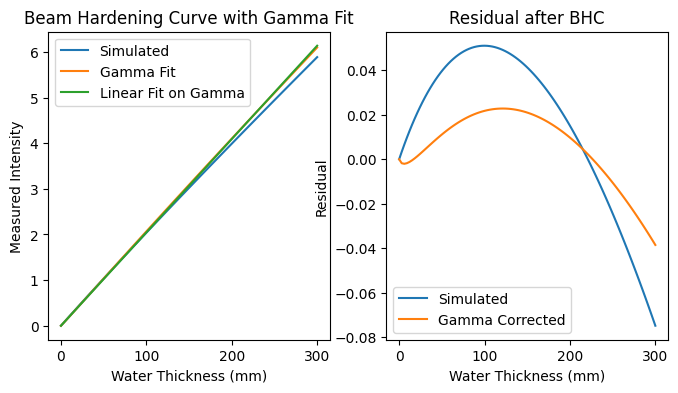

In [7]:
# Try BHC with gamma correction
# fit to y=kx^gamma
gamma, _ = np.polyfit(np.log(intensity[1:]), np.log(thicknesses[1:]), 1)
k2 = np.linalg.lstsq(thicknesses[:, None], intensity**gamma, rcond=None)[0][0]

# gamma = 1.0275
print(gamma)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(thicknesses, intensity, label='Simulated')
plt.plot(thicknesses, intensity**gamma, label='Gamma Fit')
plt.plot(thicknesses, k2 * thicknesses, label='Linear Fit on Gamma')
plt.xlabel('Water Thickness (mm)')
plt.ylabel('Measured Intensity')
plt.legend()
plt.title('Beam Hardening Curve with Gamma Fit')

plt.subplot(1, 2, 2)
plt.plot(thicknesses, intensity - k * thicknesses, label='Simulated')
plt.plot(thicknesses, intensity**gamma - k2 * thicknesses, label='Gamma Corrected')
plt.xlabel('Water Thickness (mm)')
plt.ylabel('Residual')
plt.legend()
plt.title('Residual after BHC')
plt.show()

/tmp/ipykernel_1534676/1087673073.py:1: RuntimeWarning: invalid value encountered in power
  prjs_gamma = (prjs_poly ** gamma).astype(np.float32)


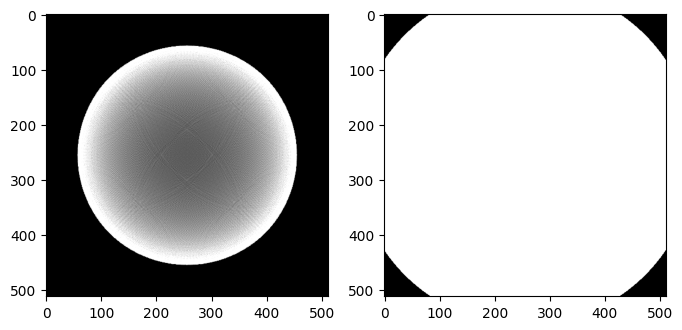

In [8]:
prjs_gamma = (prjs_poly ** gamma).astype(np.float32)
recon_gamma = leapct.FBP(prjs_gamma)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(recon_poly[0], cmap='gray', vmin=display_vmin, vmax=display_vmax)
plt.subplot(1, 2, 2)
plt.imshow(recon_gamma[0], cmap='gray', vmin=display_vmin, vmax=display_vmax)

[ 9.47553042e-01  1.46324201e-02 -6.09546150e-04]


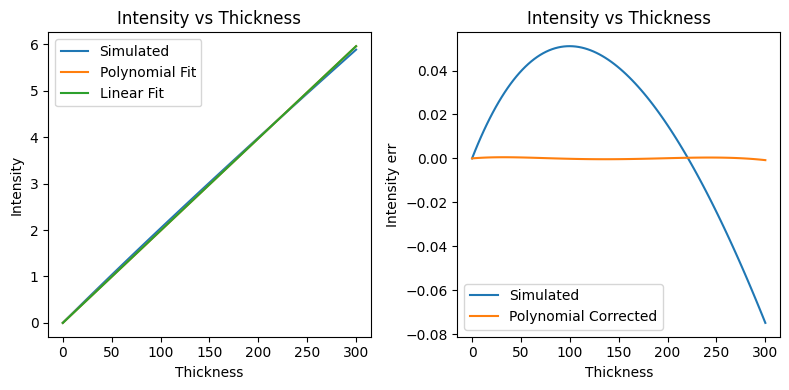

In [16]:
# polynomial fit without intercept
x = intensity
y = k * thicknesses

# build matrices
order = 3
A = np.vstack([x**i for i in range(1, order + 1)]).T
b = y
coeffs = np.linalg.lstsq(A, b, rcond=None)[0]
print(coeffs)

# apply polynomial correction
# intensity_fit_err = np.sum(coeffs[:, None] * np.vstack([x**i for i in range(1, order + 1)]), axis=0)
# intensity_fit = intensity - intensity_fit_err
intensity_fit = np.sum(coeffs[:, None] * np.vstack([x**i for i in range(1, order + 1)]), axis=0)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(thicknesses, intensity, label='Simulated')
plt.plot(thicknesses, intensity_fit, label='Polynomial Fit')
plt.plot(thicknesses, k * thicknesses, label='Linear Fit')
plt.xlabel('Thickness')
plt.ylabel('Intensity')
plt.title('Intensity vs Thickness')
plt.legend()
plt.tight_layout()

plt.subplot(1, 2, 2)
plt.plot(thicknesses, intensity - k * thicknesses, label='Simulated')
plt.plot(thicknesses, intensity_fit - k * thicknesses, label='Polynomial Corrected')
plt.xlabel('Thickness')
plt.ylabel('Intensity err')
plt.title('Intensity vs Thickness')
plt.legend()
plt.tight_layout()

plt.show()

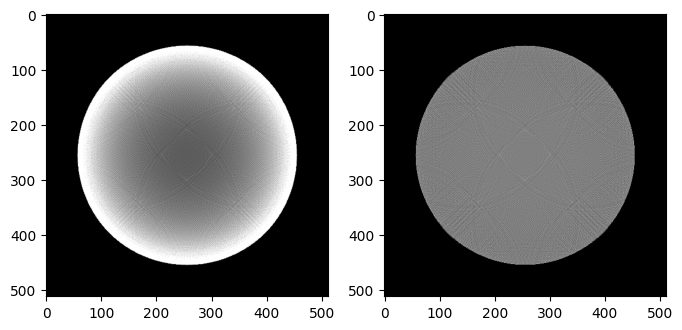

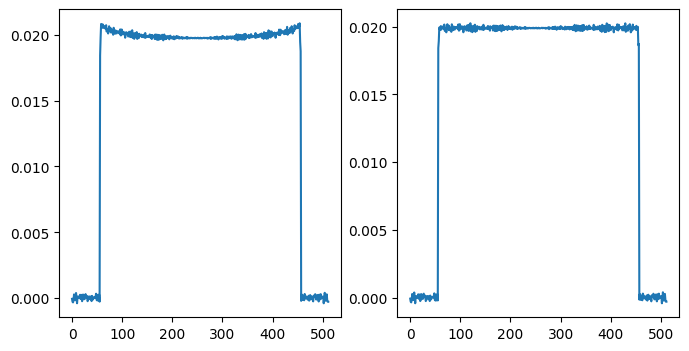

In [17]:
prjs_fit = np.sum(coeffs[:, None, None, None] * np.array([prjs_poly**i for i in range(1, order + 1)]), axis=0)
recon_fit = leapct.FBP(prjs_fit.astype(np.float32))

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(recon_poly[0], cmap='gray', vmin=display_vmin, vmax=display_vmax)
plt.subplot(1, 2, 2)
plt.imshow(recon_fit[0], cmap='gray', vmin=display_vmin, vmax=display_vmax)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(recon_poly[0, 256])
plt.subplot(1, 2, 2)
plt.plot(recon_fit[0, 256])